<a href="https://colab.research.google.com/github/gulsumdurmaz/Human-Activity-Recognition_har/blob/main/har_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings
import time
import shap
import os
import urllib.request
import zipfile
from datetime import datetime

from sklearn import metrics, linear_model
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv1D, Input, MaxPooling1D, LSTM, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# Uyarıları gizleme ve görsel ayarları
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=ConvergenceWarning)

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
strong_soft_palette = ["#4682B4", "#708238", "#BC5D58", "#8A6691", "#DAA520", "#5F9EA0"]
sns.set_palette(sns.color_palette(strong_soft_palette))

In [ ]:
#veri setini yükleme ve klasörü okuma
dataset_dir = "UCI HAR Dataset"
if not os.path.exists(dataset_dir):
    print("Veri seti UCI Repository'den indiriliyor. Lütfen bekleyin (Yaklaşık 60 MB)...")
    url = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
    urllib.request.urlretrieve(url, "har_outer.zip")

    with zipfile.ZipFile("har_outer.zip", 'r') as zip_ref:
        zip_ref.extractall()

    if os.path.exists("UCI HAR Dataset.zip"):
        with zipfile.ZipFile("UCI HAR Dataset.zip", 'r') as zip_ref:
            zip_ref.extractall()

    print("Veri seti indirildi\n")
else:
    print("Veri seti klasörü zaten mevcut.\n")

path = f'{dataset_dir}/'

Veri seti UCI Repository'den indiriliyor. Lütfen bekleyin (Yaklaşık 60 MB)...
Veri seti indirildi



In [ ]:
# 561 sütunu yükleme
features = pd.read_csv(path + "features.txt", sep="\s+", header=None)
features.columns = ["index", "feature_name"]

# eğitim setini okuma
X_train = pd.read_csv(path + "train/X_train.txt", sep="\s+", header=None)
y_train = pd.read_csv(path + "train/y_train.txt", sep="\s+", header=None)
X_train.columns = features["feature_name"]

# Test setini okuma
X_test = pd.read_csv(path + "test/X_test.txt", sep="\s+", header=None)
y_test = pd.read_csv(path + "test/y_test.txt", sep="\s+", header=None)
X_test.columns = features["feature_name"]

# Veriyi düzleştirme-> ml modelleri için veride boyut indirgeme
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print("Toplam Özellik Sayısı:", len(features))

Toplam Özellik Sayısı: 561


In [ ]:
#VERİ SETİNİN ÖN İŞLEMELİ BİR VERİ SETİ OLMASINDAN DOLAYI TEMİZLEME İŞLEMİNE GEREK DUYULMAMIŞTIR.
#BOŞ SÜTUN VE DEĞER OLMAMASI DA BUNU GÖSTERİR.

train = pd.concat([X_train, pd.DataFrame(y_train, columns=['Activity'])], axis=1)
test = pd.concat([X_test, pd.DataFrame(y_test, columns=['Activity'])], axis=1)
print('Eğitim setinde yinelenen sütun sayısı: {}'.format(sum(train.duplicated())))
print('Test setinde yinelenen sütun sayısı: {}'.format(sum(test.duplicated())))
print('Eğitim setinde {} tane boş değer var.'.format(train.isnull().values.sum()))
print('Test setinde {} tane boş değer var.'.format(test.isnull().values.sum()))

Eğitim setinde yinelenen sütun sayısı: 0
Test setinde yinelenen sütun sayısı: 0
Eğitim setinde 0 tane boş değer var.
Test setinde 0 tane boş değer var.


In [ ]:
#kodları tek boyutlu hale getirmek için kullanılan güvenli format
if len(y_train.shape) > 1:
    y_train_labels = np.argmax(y_train, axis=1)
    y_test_labels = np.argmax(y_test, axis=1)
else:
    y_train_labels = y_train
    y_test_labels = y_test
#AKTİVİTELERİ İSİMLENDİRME
activity_labels = {
    1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING', 5: 'STANDING', 6: 'LAYING'
}

train_activities = pd.Series(np.ravel(y_train)).map(activity_labels)
test_activities = pd.Series(np.ravel(y_test)).map(activity_labels)


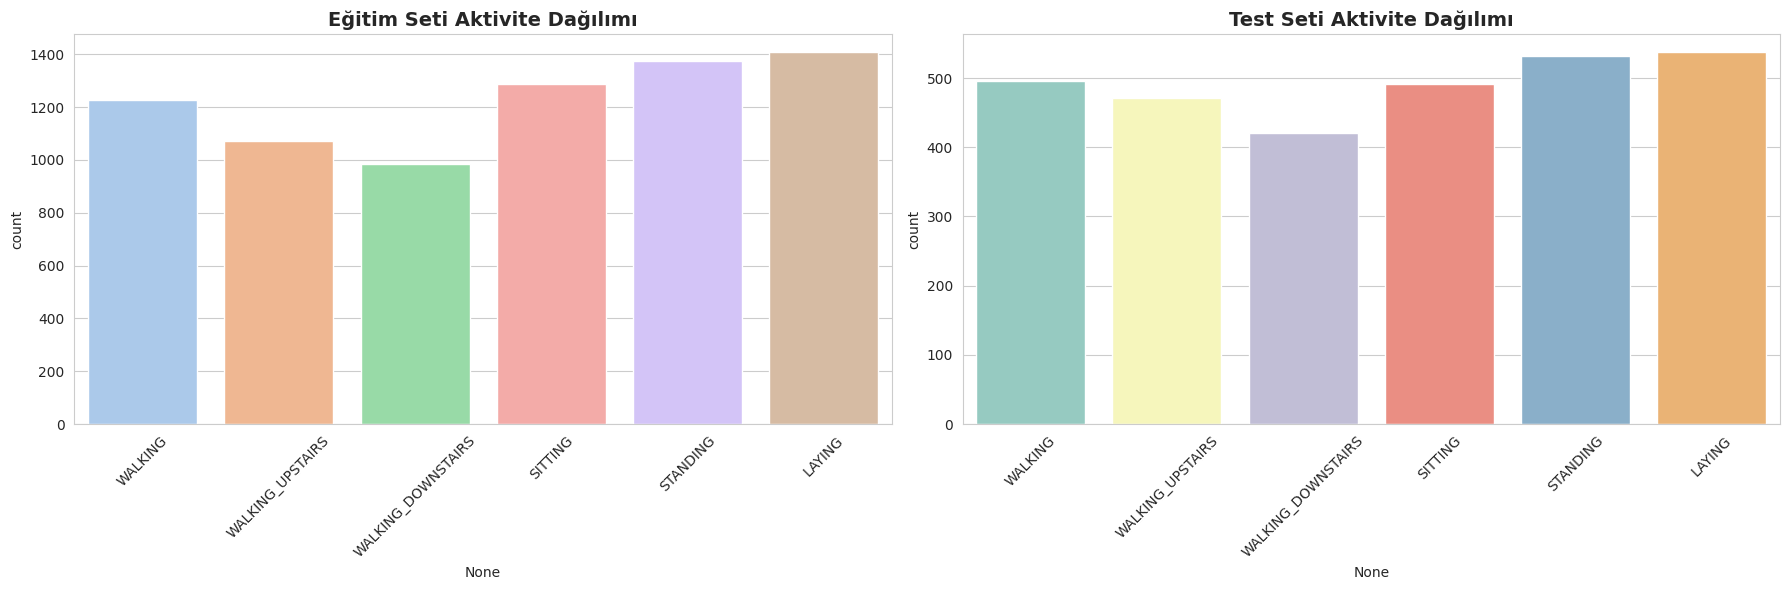

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
sns.countplot(x=train_activities, ax=ax[0], palette="pastel", order=activity_labels.values())
ax[0].set_title('Eğitim Seti Aktivite Dağılımı', fontsize=14, fontweight='bold')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)

sns.countplot(x=test_activities, ax=ax[1], palette="Set3", order=activity_labels.values())
ax[1].set_title('Test Seti Aktivite Dağılımı', fontsize=14, fontweight='bold')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

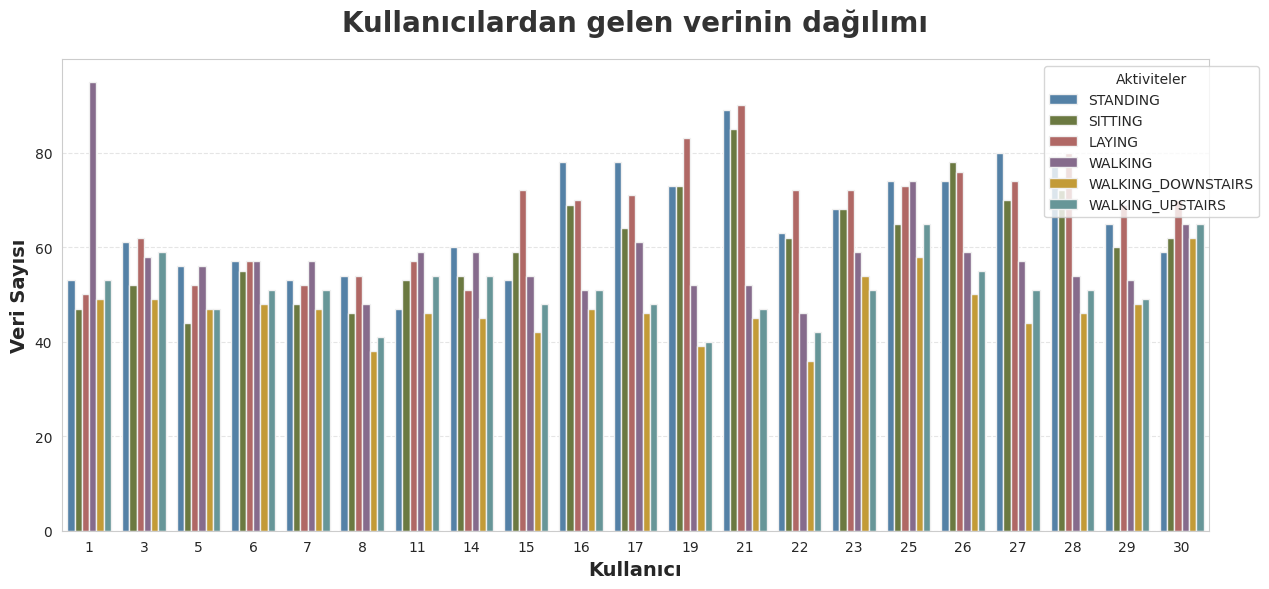

In [ ]:
subject_train = pd.read_csv(path + "train/subject_train.txt", header=None)
train['subject'] = subject_train.values.ravel()
train['ActivityName'] = train['Activity'].map(activity_labels)

plt.figure(figsize=(13, 6))
plt.title('Kullanıcılardan gelen verinin dağılımı', fontsize=20, pad=20, fontweight='bold', color='#333333')
sns.countplot(x='subject', hue='ActivityName', data=train, palette=strong_soft_palette, edgecolor="#f0f0f0", linewidth=1)
plt.xlabel('Kullanıcı', fontsize=14, fontweight='semibold')
plt.ylabel('Veri Sayısı', fontsize=14, fontweight='semibold')
plt.legend(title='Aktiviteler', bbox_to_anchor=(0.85, 1), loc='upper left', frameon=True)
plt.gca().yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
train.head(5)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity,subject,ActivityName
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,5,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,5,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,5,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,5,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,5,1,STANDING


In [ ]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.PuBu):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.RdPu, vmin= -cm.max() * 0.15)
    plt.title(title, fontsize=15, fontweight='bold')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('Gerçek Etiket')
    plt.xlabel('Tahmin Edilen Etiket')
    plt.show()

In [ ]:
def perform_model_visual(grid_model, X_train_data, y_train_data, X_test_data, y_test_data, class_labels):
    results = dict()

    train_start = datetime.now()
    grid_model.fit(X_train_data, y_train_data)
    train_end = datetime.now()
    results['training_time'] = train_end - train_start

    test_start = datetime.now()
    y_pred = grid_model.predict(X_test_data)
    test_end = datetime.now()
    results['testing_time'] = test_end - test_start

    accuracy = metrics.accuracy_score(y_test_data, y_pred)
    results['accuracy'] = accuracy
    results['model'] = grid_model

    # İsim bulma mantığı pipeline için düzeltildi
    if isinstance(grid_model.estimator, Pipeline):
        model_name = type(grid_model.estimator.named_steps['clf']).__name__
    else:
        model_name = type(grid_model.estimator).__name__

    cm = metrics.confusion_matrix(y_test_data, y_pred)
    plot_confusion_matrix(cm, classes=class_labels, normalize=True,
                          title=f'{model_name} Karmaşıklık Matrisi (CM) (%)', cmap=plt.cm.PuBu)

    print(f"\n{model_name} Accuracy: {accuracy}")
    print("-" * 60)
    print(metrics.classification_report(y_test_data, y_pred, target_names=class_labels))
    print("-" * 60)
    print(f"Eğitim Süresi: {results['training_time']}")

    return results

In [ ]:
def print_grid_search_attributes(model):
    print('\n' + '='*30)
    print('GRIDSEARCH OPTİMİZASYON SONUÇLARI')
    print('='*30)
    print(f'\tEn İyi Tahminci: {model.best_estimator_}\n')
    print(f'\tEn İyi Parametreler: {model.best_params_}\n')
    print(f'\tCross Validation set sayısı: {model.n_splits_}\n')
    print(f'\tCross Validation Skoru: %{model.best_score_*100:.2f}')
    print('='*30 + '\n')

# MAKİNE ÖĞRENMESİ MODELLERİ

Lojistik Regresyon

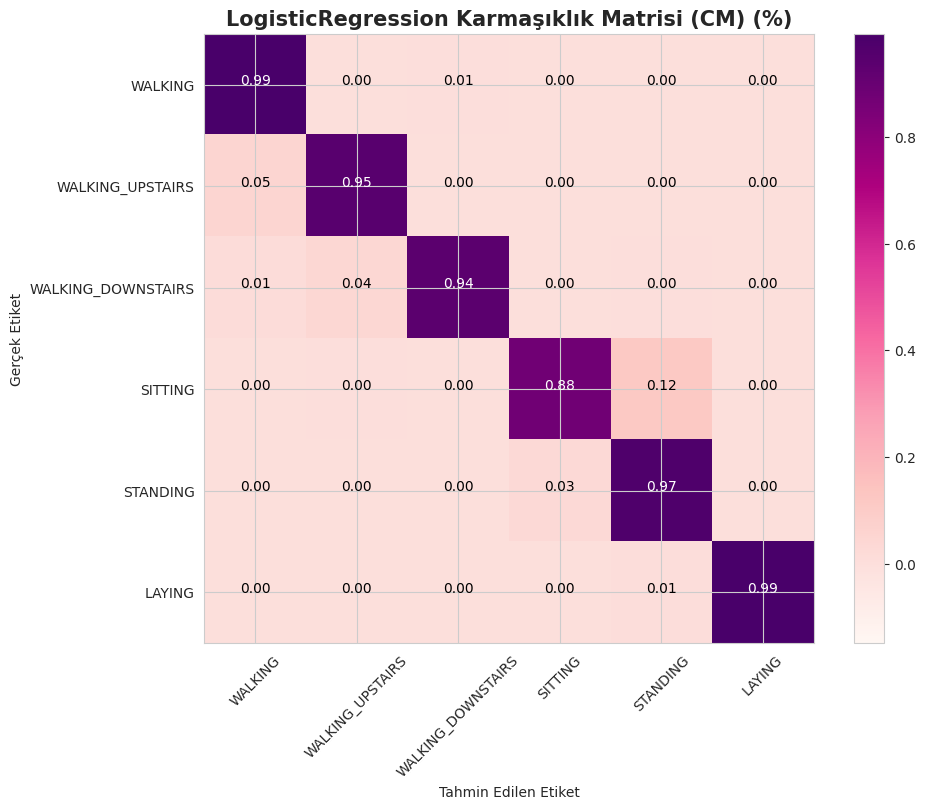


LogisticRegression Accuracy: 0.9548693586698337
------------------------------------------------------------
                    precision    recall  f1-score   support

           WALKING       0.94      0.99      0.97       496
  WALKING_UPSTAIRS       0.96      0.95      0.95       471
WALKING_DOWNSTAIRS       0.99      0.94      0.96       420
           SITTING       0.97      0.88      0.92       491
          STANDING       0.89      0.97      0.93       532
            LAYING       1.00      0.99      0.99       537

          accuracy                           0.95      2947
         macro avg       0.96      0.95      0.95      2947
      weighted avg       0.96      0.95      0.95      2947

------------------------------------------------------------
Eğitim Süresi: 0:00:19.867553

GRIDSEARCH OPTİMİZASYON SONUÇLARI
	En İyi Tahminci: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(C=1, max_iter=1000))])

	En İyi Parametreler: {'clf__C

In [ ]:
parameters = {'clf__C':[0.1, 1, 3], 'clf__penalty':['l2']}
pipe_lr = Pipeline([('scaler', StandardScaler()), ('clf', linear_model.LogisticRegression(max_iter=1000))])
log_reg_grid = GridSearchCV(pipe_lr, param_grid=parameters, cv=3, verbose=0, n_jobs=-1)
log_reg_grid_results = perform_model_visual(log_reg_grid, X_train, y_train, X_test, y_test, class_labels=list(activity_labels.values()))
print_grid_search_attributes(log_reg_grid_results['model'])


Linear SVC

Fitting 3 folds for each of 3 candidates, totalling 9 fits


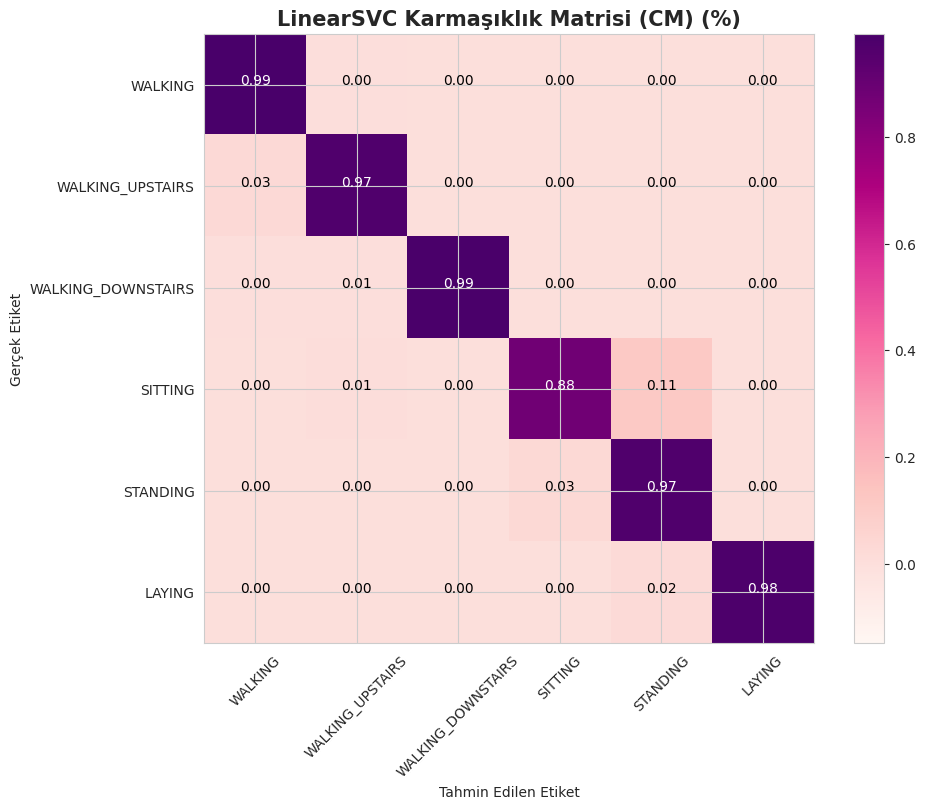


LinearSVC Accuracy: 0.9623345775364778
------------------------------------------------------------
                    precision    recall  f1-score   support

           WALKING       0.97      0.99      0.98       496
  WALKING_UPSTAIRS       0.98      0.97      0.98       471
WALKING_DOWNSTAIRS       1.00      0.99      0.99       420
           SITTING       0.96      0.88      0.92       491
          STANDING       0.88      0.97      0.92       532
            LAYING       1.00      0.98      0.99       537

          accuracy                           0.96      2947
         macro avg       0.97      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947

------------------------------------------------------------
Eğitim Süresi: 0:00:33.492003

GRIDSEARCH OPTİMİZASYON SONUÇLARI
	En İyi Tahminci: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LinearSVC(C=0.065, dual=False, max_iter=10000, tol=5e-05))])

	En

In [ ]:
parameters = {'clf__C':[0.06, 0.065, 0.07]}
pipe_svc = Pipeline([('scaler', StandardScaler()), ('clf', LinearSVC(tol=0.00005, max_iter=10000, dual=False))])
lr_svc_grid = GridSearchCV(pipe_svc, param_grid=parameters, cv=3, n_jobs=-1, verbose=1)
lr_svc_grid_results = perform_model_visual(lr_svc_grid, X_train, y_train, X_test, y_test, class_labels=list(activity_labels.values()))
print_grid_search_attributes(lr_svc_grid_results['model'])

SVM(rbf)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


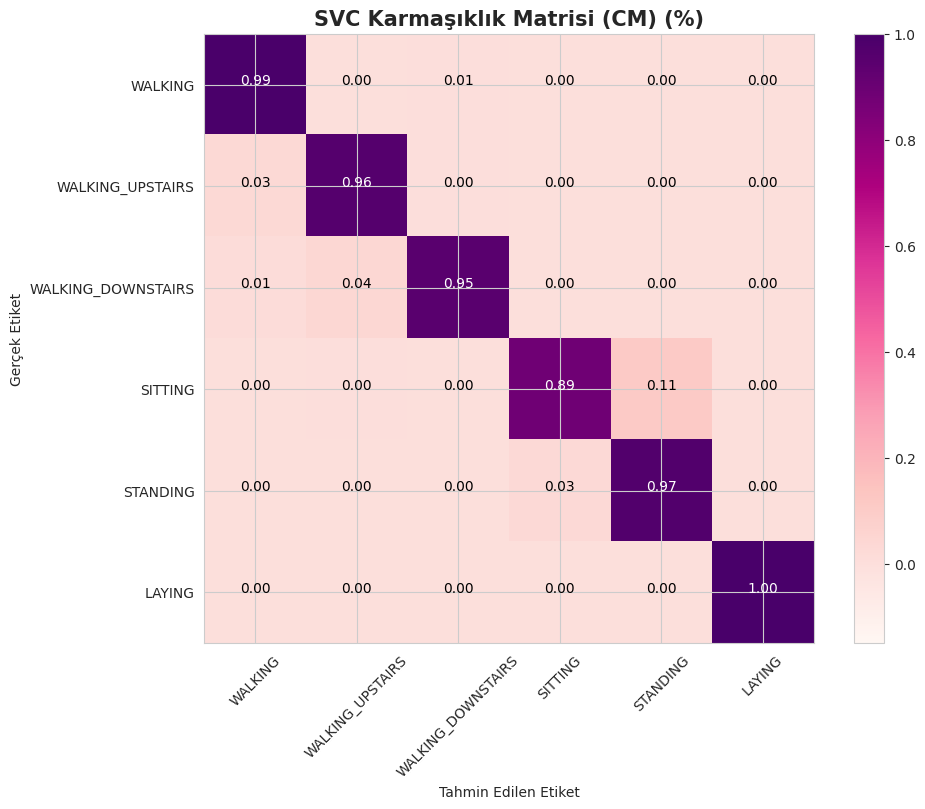


SVC Accuracy: 0.9613165931455717
------------------------------------------------------------
                    precision    recall  f1-score   support

           WALKING       0.96      0.99      0.98       496
  WALKING_UPSTAIRS       0.96      0.96      0.96       471
WALKING_DOWNSTAIRS       0.99      0.95      0.97       420
           SITTING       0.97      0.89      0.92       491
          STANDING       0.91      0.97      0.94       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947

------------------------------------------------------------
Eğitim Süresi: 0:00:54.917888

GRIDSEARCH OPTİMİZASYON SONUÇLARI
	En İyi Tahminci: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', SVC(C=1000, gamma=0.0001))])

	En İyi Parametreler: {'clf__C': 1000, 'clf__gamma': 0.000

In [ ]:
parameters=[{'clf__kernel': ['rbf'], 'clf__gamma': [0.0001, 0.00005], 'clf__C': [100, 1000, 10000]},
            {'clf__kernel': ['linear'], 'clf__C': [1, 10, 100, 1000]}]
pipe_rbf = Pipeline([('scaler', StandardScaler()), ('clf', SVC())])
rbf_svm_grid = GridSearchCV(pipe_rbf, param_grid=parameters, cv=4, n_jobs=-1, verbose=4)
rbf_svm_grid_results = perform_model_visual(rbf_svm_grid, X_train, y_train, X_test, y_test, class_labels=list(activity_labels.values()))
print_grid_search_attributes(rbf_svm_grid_results['model'])

Decision Tree

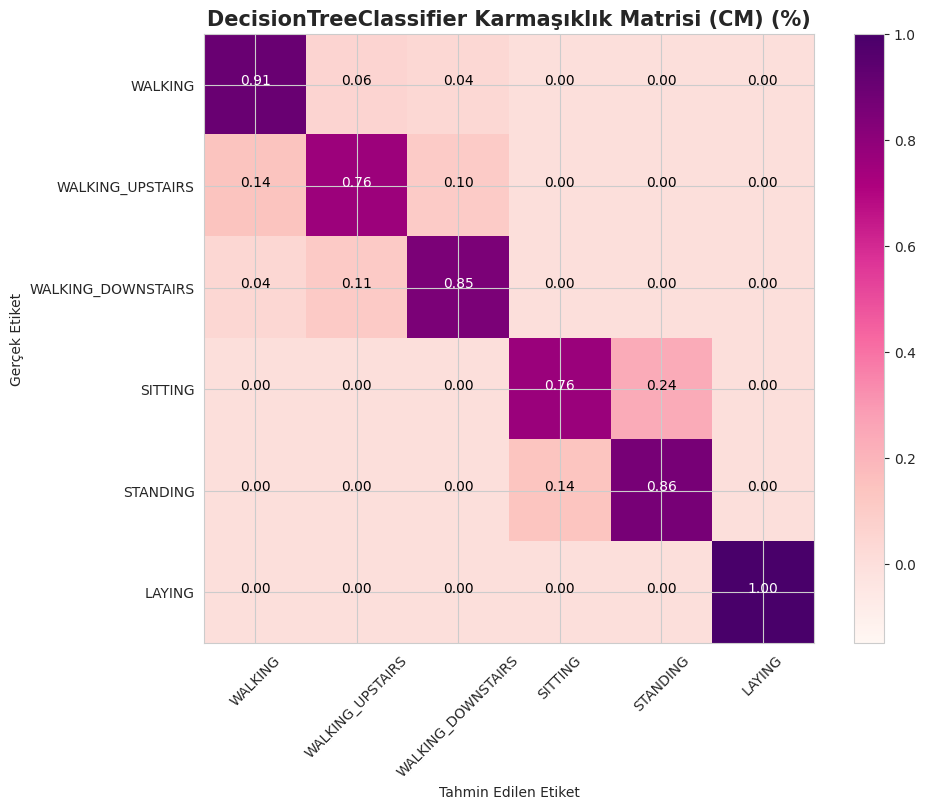


DecisionTreeClassifier Accuracy: 0.8601968103155752
------------------------------------------------------------
                    precision    recall  f1-score   support

           WALKING       0.85      0.91      0.87       496
  WALKING_UPSTAIRS       0.83      0.76      0.79       471
WALKING_DOWNSTAIRS       0.84      0.85      0.85       420
           SITTING       0.84      0.76      0.80       491
          STANDING       0.80      0.86      0.83       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.86      2947
         macro avg       0.86      0.86      0.86      2947
      weighted avg       0.86      0.86      0.86      2947

------------------------------------------------------------
Eğitim Süresi: 0:01:16.097055

GRIDSEARCH OPTİMİZASYON SONUÇLARI
	En İyi Tahminci: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', DecisionTreeClassifier(max_depth=17))])

	En İyi Parametreler: {'clf_

In [ ]:
parameters = {'clf__max_depth': [13, 15, 17]}
pipe_dt = Pipeline([('scaler', StandardScaler()), ('clf', DecisionTreeClassifier())])
dt_grid = GridSearchCV(pipe_dt, param_grid=parameters, n_jobs=-1)
dt_grid_results = perform_model_visual(dt_grid, X_train, y_train, X_test, y_test, class_labels=list(activity_labels.values()))
print_grid_search_attributes(dt_grid_results['model'])

Random Forest Classsifier

Fitting 3 folds for each of 6 candidates, totalling 18 fits


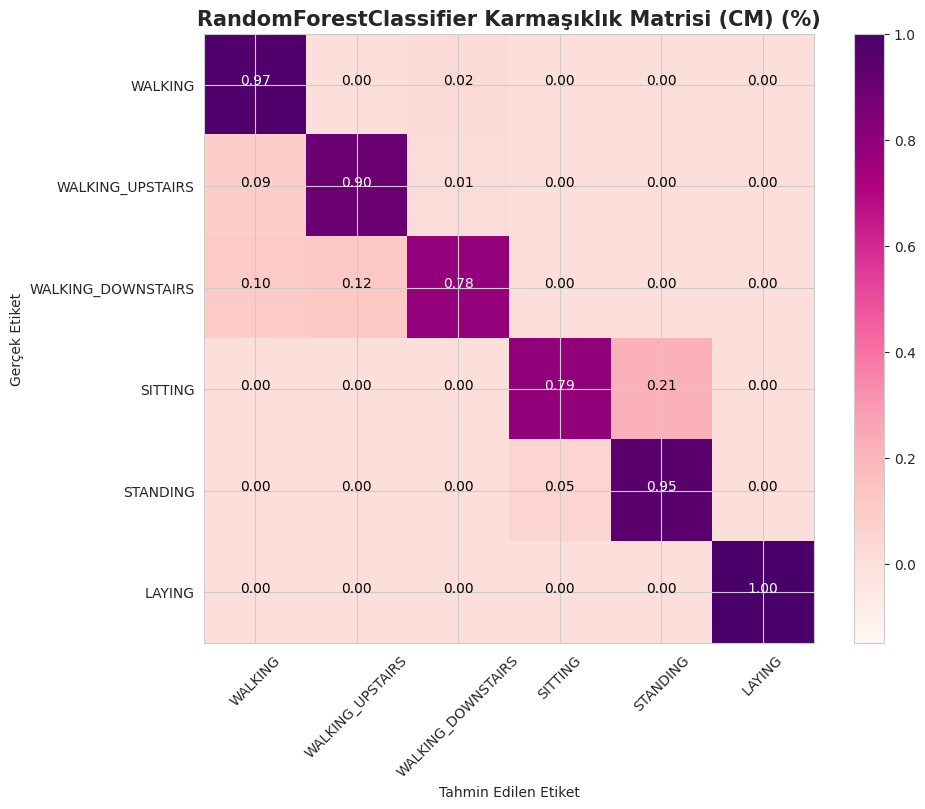


RandomForestClassifier Accuracy: 0.9032914828639295
------------------------------------------------------------
                    precision    recall  f1-score   support

           WALKING       0.85      0.97      0.91       496
  WALKING_UPSTAIRS       0.89      0.90      0.90       471
WALKING_DOWNSTAIRS       0.95      0.78      0.86       420
           SITTING       0.93      0.79      0.85       491
          STANDING       0.83      0.95      0.88       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.90      2947
         macro avg       0.91      0.90      0.90      2947
      weighted avg       0.91      0.90      0.90      2947

------------------------------------------------------------
Eğitim Süresi: 0:01:15.866808

GRIDSEARCH OPTİMİZASYON SONUÇLARI
	En İyi Tahminci: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', RandomForestClassifier(max_depth=6, n_estimators=60))])

	En İyi Para

In [ ]:
params = {'clf__n_estimators': [50,60], 'clf__max_depth': [6, 7, 8]}
pipe_rfc = Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier())])
rfc_grid = GridSearchCV(pipe_rfc, param_grid=params, n_jobs=-1, cv=3, verbose=1)
rfc_grid_results = perform_model_visual(rfc_grid, X_train, y_train, X_test, y_test, class_labels=list(activity_labels.values()))
print_grid_search_attributes(rfc_grid_results['model'])

KNN

Fitting 5 folds for each of 2 candidates, totalling 10 fits


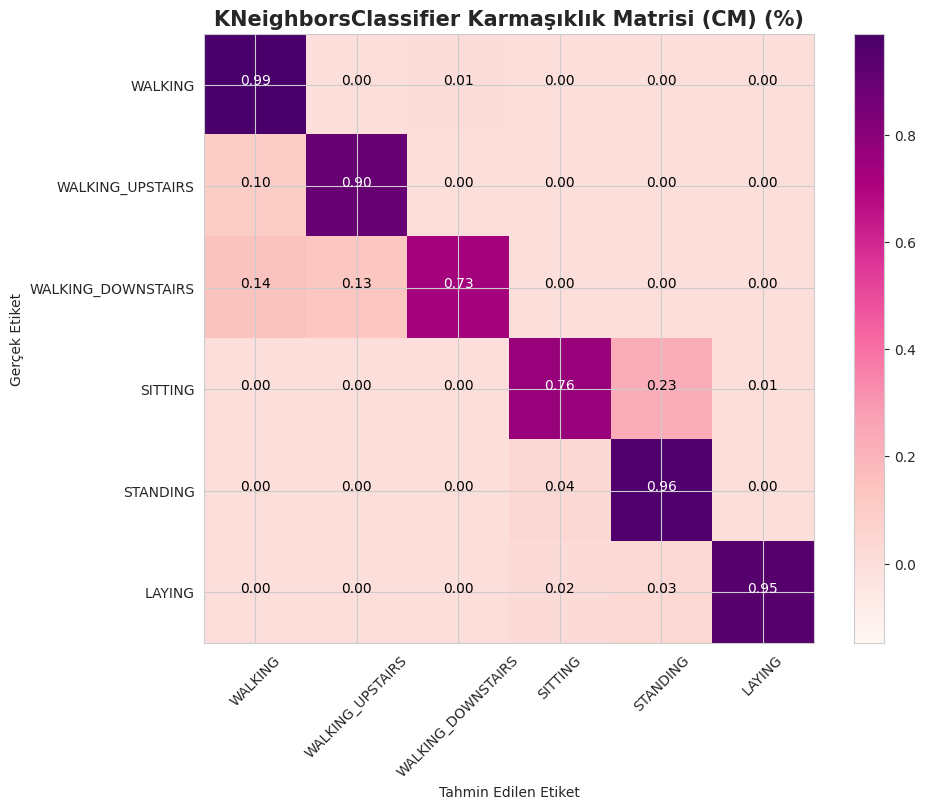


KNeighborsClassifier Accuracy: 0.8863250763488293
------------------------------------------------------------
                    precision    recall  f1-score   support

           WALKING       0.82      0.99      0.90       496
  WALKING_UPSTAIRS       0.88      0.90      0.89       471
WALKING_DOWNSTAIRS       0.98      0.73      0.84       420
           SITTING       0.92      0.76      0.83       491
          STANDING       0.80      0.96      0.87       532
            LAYING       0.99      0.95      0.97       537

          accuracy                           0.89      2947
         macro avg       0.90      0.88      0.88      2947
      weighted avg       0.90      0.89      0.89      2947

------------------------------------------------------------
Eğitim Süresi: 0:00:04.506266

GRIDSEARCH OPTİMİZASYON SONUÇLARI
	En İyi Tahminci: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', KNeighborsClassifier(n_neighbors=15))])

	En İyi Parametreler: {'clf__n

In [ ]:
parameters = {'clf__n_neighbors': [15, 19]}
pipe_knn = Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())])
knn_grid = GridSearchCV(pipe_knn, param_grid=parameters, n_jobs=-1, verbose=1)
knn_grid_results = perform_model_visual(knn_grid, X_train, y_train, X_test, y_test, class_labels=list(activity_labels.values()))
print_grid_search_attributes(knn_grid_results['model'])

In [ ]:
print('\n                     Accuracy     Error')
print('                     ----------   --------')
print('Logistic Regression : {:.04}%       {:.04}%'.format(log_reg_grid_results['accuracy'] * 100, 100-(log_reg_grid_results['accuracy'] * 100)))
print('Linear SVC          : {:.04}%       {:.04}% '.format(lr_svc_grid_results['accuracy'] * 100, 100-(lr_svc_grid_results['accuracy'] * 100)))
print('RBF SVM classifier  : {:.04}%      {:.04}% '.format(rbf_svm_grid_results['accuracy'] * 100, 100-(rbf_svm_grid_results['accuracy'] * 100)))
print('DecisionTree        : {:.04}%      {:.04}% '.format(dt_grid_results['accuracy'] * 100, 100-(dt_grid_results['accuracy'] * 100)))
print('Random Forest       : {:.04}%      {:.04}% '.format(rfc_grid_results['accuracy'] * 100, 100-(rfc_grid_results['accuracy'] * 100)))
print('KNN                 : {:.04}%      {:.04}% '.format(knn_grid_results['accuracy'] * 100, 100-(knn_grid_results['accuracy'] * 100)))




                     Accuracy     Error
                     ----------   --------
Logistic Regression : 95.49%       4.513%
Linear SVC          : 96.23%       3.767% 
RBF SVM classifier  : 96.13%      3.868% 
DecisionTree        : 86.02%      13.98% 
Random Forest       : 90.94%      9.06% 
KNN                 : 88.63%      11.37% 


In [ ]:
print("\n" + "#"*50)
print("ÖZGÜN DEĞER 1: HİYERARŞİK KARAR AĞACI MİMARİSİ")
print("#"*50)

# Adım 1: Etiketleri İkili (Binary) Formata Çevirme
# 1,2,3 (Yürüme türevleri) -> Dinamik (0) | 4,5,6 (Oturma türevleri) -> Statik (1)
y_train_binary = np.where(y_train <= 3, 0, 1)
y_test_binary = np.where(y_test <= 3, 0, 1)

# Aşama 1: Sadece Statik mi Dinamik mi olduğunu tahmin eden "Üst Model"
pipe_hierarchical_top = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

print("Aşama 1 Eğitiliyor: Dinamik (Hareket) vs Statik (Durma) Ayrımı...")
pipe_hierarchical_top.fit(X_train, y_train_binary)
y_pred_binary = pipe_hierarchical_top.predict(X_test)

acc_binary = metrics.accuracy_score(y_test_binary, y_pred_binary)
print(f"Üst Model (Statik/Dinamik Ayrımı) Doğruluğu: %{acc_binary*100:.2f}")

# Aşama 2: Alt Modellerin Eğitimi (Uzman Modeller)
# Sadece dinamik verilerle eğitilen model
X_train_dyn, y_train_dyn = X_train[y_train <= 3], y_train[y_train <= 3]
pipe_dyn = Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))])
pipe_dyn.fit(X_train_dyn, y_train_dyn)

# Sadece statik verilerle eğitilen model
X_train_stat, y_train_stat = X_train[y_train > 3], y_train[y_train > 3]
pipe_stat = Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))])
pipe_stat.fit(X_train_stat, y_train_stat)

# Nihai Tahminleri Hiyerarşik Olarak Birleştirme (Vektörize edilmiş süper hızlı yöntem)
y_pred_hierarchical = np.zeros_like(y_test)
static_mask = (y_pred_binary == 1)
dynamic_mask = (y_pred_binary == 0)

if np.any(static_mask):
    y_pred_hierarchical[static_mask] = pipe_stat.predict(X_test[static_mask])
if np.any(dynamic_mask):
    y_pred_hierarchical[dynamic_mask] = pipe_dyn.predict(X_test[dynamic_mask])

print("\n--- HİYERARŞİK MODEL (AŞAMALI) DETAYLI SINIFLANDIRMA RAPORU ---")
print(classification_report(y_test, y_pred_hierarchical, target_names=list(activity_labels.values())))


##################################################
ÖZGÜN DEĞER 1: HİYERARŞİK KARAR AĞACI MİMARİSİ
##################################################
Aşama 1 Eğitiliyor: Dinamik (Hareket) vs Statik (Durma) Ayrımı...
Üst Model (Statik/Dinamik Ayrımı) Doğruluğu: %100.00

--- HİYERARŞİK MODEL (AŞAMALI) DETAYLI SINIFLANDIRMA RAPORU ---
                    precision    recall  f1-score   support

           WALKING       0.89      0.97      0.93       496
  WALKING_UPSTAIRS       0.90      0.91      0.91       471
WALKING_DOWNSTAIRS       0.96      0.85      0.90       420
           SITTING       0.92      0.90      0.91       491
          STANDING       0.91      0.93      0.92       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



# CNN/LSTM HİBRİT MODEL

Bu adımda ml modellerinde kullanılan işlenmiş 2 boyutlu veriler yerine bu adımda 3boyutlu ham veriler kullanıldı; ivmeölçer ve jiroskoptan gelen titreşimlerin orijinal kayıtları yani.

*1D: deneydeki toplam hareket sayısı

*2D: her hareketin 128 ms kesiti

*3D: 9 sensörün kayıtları

----------------------------------
  Feature Engineering işini cnn katmanlarının kendi kararına bırakıyoruz.



In [ ]:
SIGNALS = ["body_acc_x", "body_acc_y", "body_acc_z", "body_gyro_x", "body_gyro_y", "body_gyro_z", "total_acc_x", "total_acc_y", "total_acc_z"]

def load_signals(subset):
    signals_data = []
    for signal in SIGNALS:
        filename = f'{path}{subset}/Inertial Signals/{signal}_{subset}.txt'
        data = pd.read_csv(filename, delim_whitespace=True, header=None).to_numpy()
        signals_data.append(data)
    return np.transpose(signals_data, (1, 2, 0))

def load_y(subset):
    filename = f'{path}{subset}/y_{subset}.txt'
    y = pd.read_csv(filename, delim_whitespace=True, header=None)[0]
    return pd.get_dummies(y).to_numpy()

In [ ]:
X_train_dl_raw = load_signals('train')
X_test_dl = load_signals('test')
y_train_dl_raw = load_y('train')
y_test_dl = load_y('test')

In [ ]:
#Validasyon veri setini test setinden bağımsız ayırıyoruz.
X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(
    X_train_dl_raw, y_train_dl_raw, test_size=0.1, random_state=42, stratify=np.argmax(y_train_dl_raw, axis=1)
)

In [ ]:
def scale_inertial_signals_dl(X_train_data, X_val_data, X_test_data):
    X_train_flat = X_train_data.reshape(-1, X_train_data.shape[-1])
    X_val_flat = X_val_data.reshape(-1, X_val_data.shape[-1])
    X_test_flat = X_test_data.reshape(-1, X_test_data.shape[-1])

    scaler_dl = StandardScaler()
    X_train_scaled_dl = scaler_dl.fit_transform(X_train_flat).reshape(X_train_data.shape)
    X_val_scaled_dl = scaler_dl.transform(X_val_flat).reshape(X_val_data.shape)
    X_test_scaled_dl = scaler_dl.transform(X_test_flat).reshape(X_test_data.shape)
    return X_train_scaled_dl, X_val_scaled_dl, X_test_scaled_dl

X_train_dl, X_val_dl, X_test_dl = scale_inertial_signals_dl(X_train_dl, X_val_dl, X_test_dl)

n_timesteps, n_features = X_train_dl.shape[1], X_train_dl.shape[2]
n_outputs = y_train_dl.shape[1]

In [ ]:
inputs = Input(shape=(n_timesteps, n_features))

b1 = Conv1D(64, 3, padding='same')(inputs)
b1 = BatchNormalization()(b1)
b1 = Activation('relu')(b1)

b2 = Conv1D(64, 5, padding='same')(inputs)
b2 = BatchNormalization()(b2)
b2 = Activation('relu')(b2)

b3 = Conv1D(64, 7, padding='same')(inputs)
b3 = BatchNormalization()(b3)
b3 = Activation('relu')(b3)

merged = Concatenate(axis=-1)([b1, b2, b3])
merged = MaxPooling1D(pool_size=2)(merged)
merged = Dropout(0.4)(merged)
merged = LSTM(128, return_sequences=False)(merged)
merged = Dropout(0.4)(merged)

dense = Dense(64, activation='relu')(merged)
outputs = Dense(n_outputs, activation='softmax')(dense)

In [ ]:
hybrid_model = Model(inputs=inputs, outputs=outputs)

opt = Adam(learning_rate=0.001)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

hybrid_model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
print("\nHibrit Model Eğitimi Başlıyor...")
start_time = time.time()
history = hybrid_model.fit(
    X_train_dl, y_train_dl,
    epochs=40,
    batch_size=32,
    validation_data=(X_val_dl, y_val_dl), # Test yerine yeni ayrılan val seti kullanılıyor
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

train_time = time.time() - start_time
print(f"\nEğitim süresi: {train_time:.2f} saniye")
hybrid_loss, hybrid_accuracy = hybrid_model.evaluate(X_test_dl, y_test_dl, verbose=0)
print(f"\nHybrid Model Acc: {hybrid_accuracy * 100:.2f}%")

y_pred = hybrid_model.predict(X_test_dl, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_dl, axis=1)

target_names = [activity_labels[i+1] for i in range(len(activity_labels))]
print("\n--- DETAYLI SINIFLANDIRMA RAPORU ---")
print(classification_report(y_true, y_pred_classes, target_names=target_names))



Hibrit Model Eğitimi Başlıyor...
Epoch 1/40
207/207 ━━━━━━━━━━━━━━━━━━━━ 38s 158ms/step - accuracy: 0.8268 - loss: 0.4312 - val_accuracy: 0.9348 - val_loss: 0.1452 - learning_rate: 0.0010
Epoch 2/40
207/207 ━━━━━━━━━━━━━━━━━━━━ 34s 162ms/step - accuracy: 0.9320 - loss: 0.1629 - val_accuracy: 0.9538 - val_loss: 0.1213 - learning_rate: 0.0010
Epoch 3/40
207/207 ━━━━━━━━━━━━━━━━━━━━ 32s 154ms/step - accuracy: 0.9403 - loss: 0.1402 - val_accuracy: 0.9565 - val_loss: 0.0983 - learning_rate: 0.0010
Epoch 4/40
207/207 ━━━━━━━━━━━━━━━━━━━━ 34s 163ms/step - accuracy: 0.9424 - loss: 0.1416 - val_accuracy: 0.9484 - val_loss: 0.1096 - learning_rate: 0.0010
Epoch 5/40
207/207 ━━━━━━━━━━━━━━━━━━━━ 32s 156ms/step - accuracy: 0.9456 - loss: 0.1321 - val_accuracy: 0.9538 - val_loss: 0.1078 - learning_rate: 0.0010
Epoch 6/40
207/207 ━━━━━━━━━━━━━━━━━━━━ 34s 165ms/step - accuracy: 0.9438 - loss: 0.1348 - val_accuracy: 0.9606 - val_loss: 0.0968 - learning_rate: 0.0010
Epoch 7/40
207/207 ━━━━━━━━━━━━━━━━━

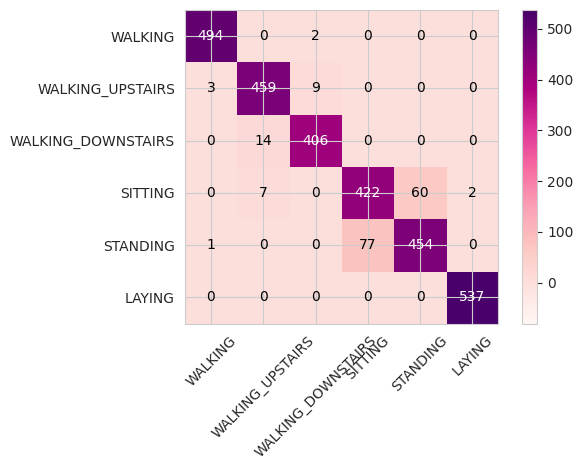

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.imshow(cm,cmap=plt.cm.RdPu, vmin= -cm.max() * 0.15)
plt.colorbar()

plt.xticks(np.arange(len(activity_labels)), list(activity_labels.values()), rotation=45)
plt.yticks(np.arange(len(activity_labels)), list(activity_labels.values()))

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()


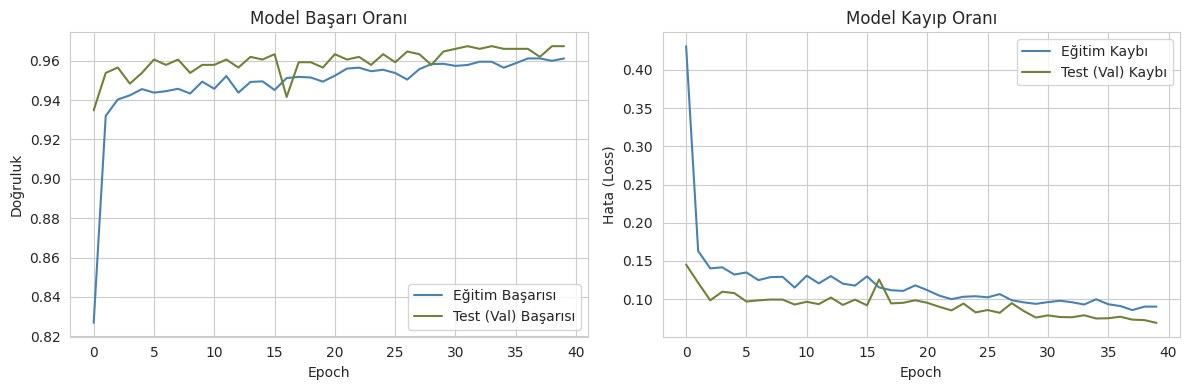

In [ ]:
def plot_learning_curves(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Eğitim Başarısı')
    plt.plot(history.history['val_accuracy'], label='Test (Val) Başarısı')
    plt.title('Model Başarı Oranı')
    plt.xlabel('Epoch')
    plt.ylabel('Doğruluk')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Eğitim Kaybı')
    plt.plot(history.history['val_loss'], label='Test (Val) Kaybı')
    plt.title('Model Kayıp Oranı')
    plt.xlabel('Epoch')
    plt.ylabel('Hata (Loss)')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_learning_curves(history)

Ek Görseller

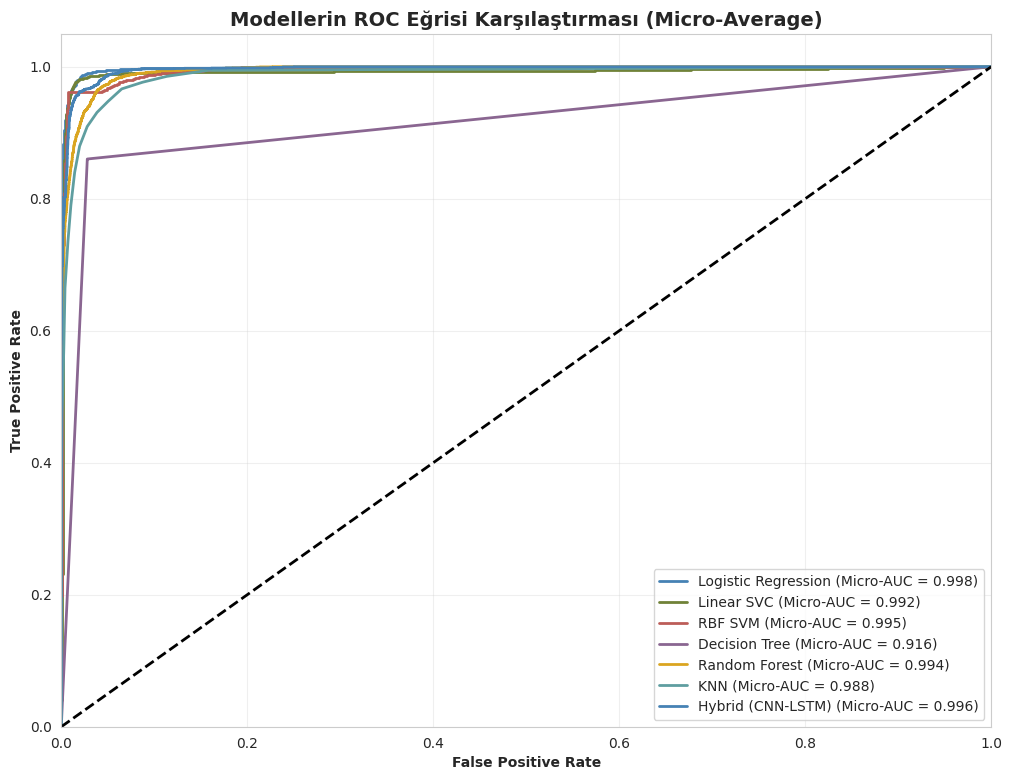

In [ ]:
y_test_bin = label_binarize(y_test_labels, classes=np.unique(y_test_labels))

all_models = {
    'Logistic Regression': log_reg_grid_results['model'],
    'Linear SVC': lr_svc_grid_results['model'],
    'RBF SVM': rbf_svm_grid_results['model'],
    'Decision Tree': dt_grid_results['model'],
    'Random Forest': rfc_grid_results['model'],
    'KNN': knn_grid_results['model'],
    'Hybrid (CNN-LSTM)': hybrid_model
}

plt.figure(figsize=(12, 9))

for name, clf in all_models.items():
    if name == 'Hybrid (CNN-LSTM)':
        y_score = clf.predict(X_test_dl, verbose=0)
    else:
        # Pipeline kullanıldığı için özellik çekimi best_estimator üzerinden yapılıyor
        final_estimator = clf.best_estimator_.named_steps['clf']
        # X_test ham olarak pipe'a verilir, pipe kendi içinde scaler'ı uygular
        if hasattr(final_estimator, "predict_proba"):
            y_score = clf.predict_proba(X_test)
        else:
            decision_scores = clf.decision_function(X_test)
            y_score = (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min())

    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (Micro-AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('Modellerin ROC Eğrisi Karşılaştırması (Micro-Average)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

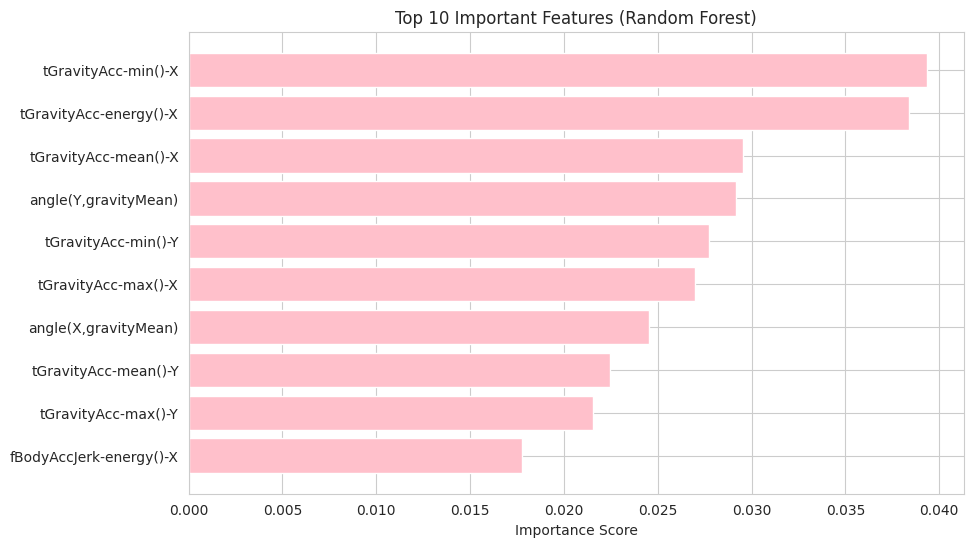

In [ ]:
# Random Forest için En Önemli 10 Özellik (Pipeline mimarisine göre güncellendi)
importances = rfc_grid_results['model'].best_estimator_.named_steps['clf'].feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='pink')
plt.yticks(range(len(indices)), X_train.columns[indices])
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

ÖZGÜN DEĞER 2: XAI - SHAP ANALİZİ HESAPLANIYOR


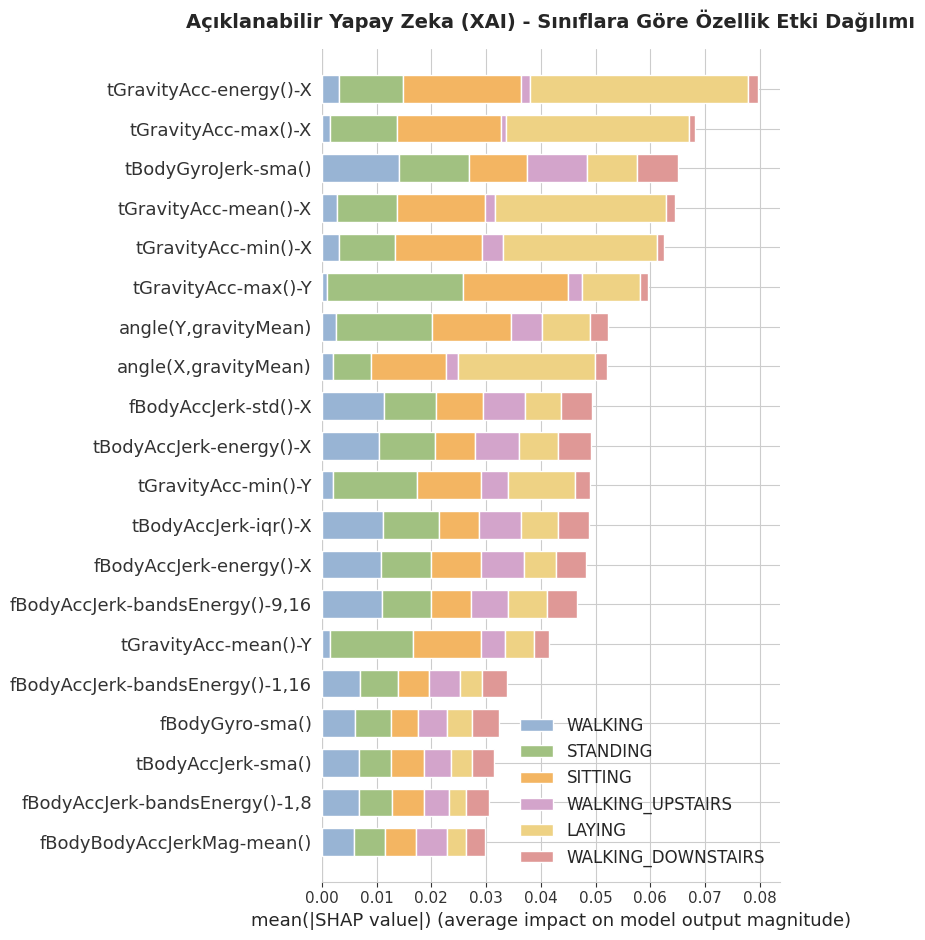

In [ ]:
# YENİ ÖZGÜN DEĞER 2: XAI AÇIKLANABİLİR YAPAY ZEKA
print("ÖZGÜN DEĞER 2: XAI - SHAP ANALİZİ HESAPLANIYOR")

# Daha önce Pipeline ile eğittiğimiz en iyi Random Forest modelini içinden çekiyoruz
best_rf_model = rfc_grid_results['model'].best_estimator_.named_steps['clf']
scaler_rf = rfc_grid_results['model'].best_estimator_.named_steps['scaler']

# SHAP, Pipeline'ı doğrudan okuyamadığı için test verisini sadece analiz için ölçekliyoruz
X_test_scaled_shap = scaler_rf.transform(X_test)

# SHAP hesaplaması ağır bir matematiksel işlemdir. Süreyi optimize etmek için
np.random.seed(42)
sample_indices = np.random.choice(X_test_scaled_shap.shape[0], 200, replace=False)
X_test_sample = X_test_scaled_shap[sample_indices]
X_test_sample_df = X_test.iloc[sample_indices] # Sütun isimlerini korumak için

# TreeExplainer ile SHAP Karar Değerlerini Oluşturma
explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer.shap_values(X_test_sample)

# Makalede okunabilirliği artırmak için aktivite isimlerini listeye çekiyoruz
class_names = list(activity_labels.values())

# Grafiği çizdirme alanı
plt.figure(figsize=(14, 8))
plt.title("Açıklanabilir Yapay Zeka (XAI) - Sınıflara Göre Özellik Etki Dağılımı", fontweight='bold', fontsize=14, pad=15)

# Dengeyi sağlayan, mat ama belirgin elegan pastel renk paleti
balanced_soft_pastels = [
    '#98B4D4',
    '#A1C181',
    '#F3B562',
    '#D3A4CB',
    '#EED284',
    '#DF9896'
]

# Convert the list of colors to a ListedColormap
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(balanced_soft_pastels)

# Grafiği özel renkler ve sınıf isimleriyle oluşturuyoruz
shap.summary_plot(
    shap_values,
    X_test_sample_df,
    plot_type="bar",
    class_names=class_names,
    color=custom_cmap,
    show=False
)

plt.tight_layout()
plt.show()

TÜM MODELLERİN BAŞARI ORANLARI KARŞILAŞTIRILIYOR


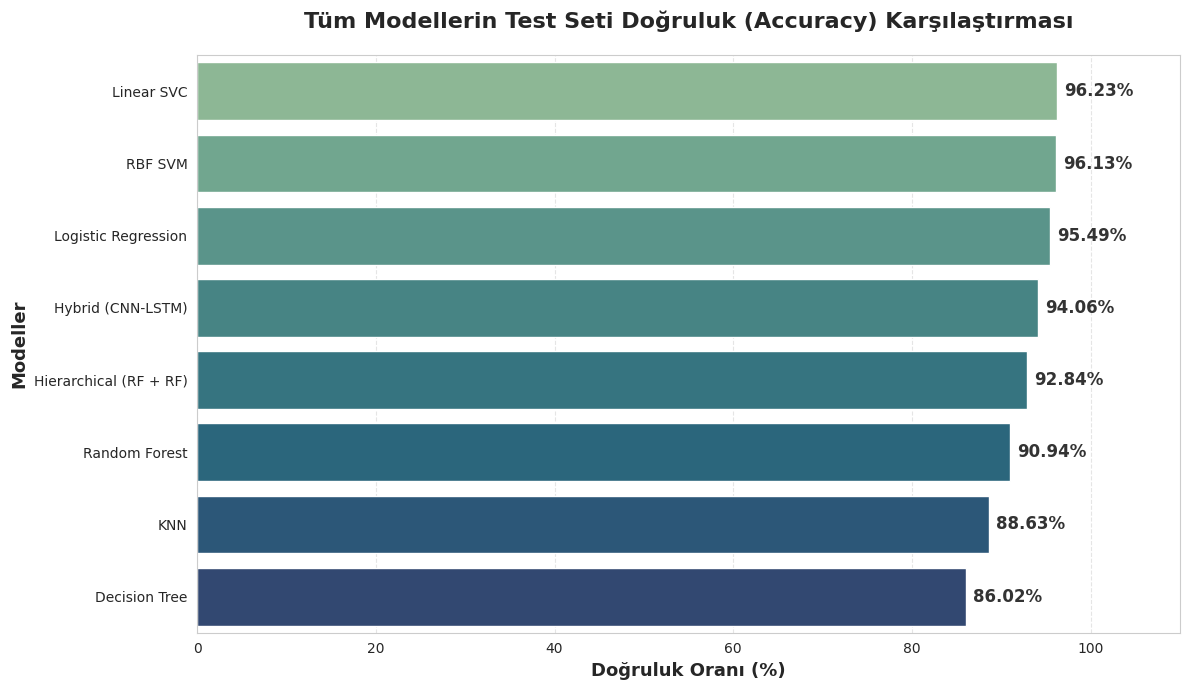

In [ ]:
# TÜM MODELLERİN DOĞRULUK (ACCURACY) KARŞILAŞTIRMA GRAFİĞİ
print("TÜM MODELLERİN BAŞARI ORANLARI KARŞILAŞTIRILIYOR")

# Makine öğrenmesi ve Derin Öğrenme modellerinin doğruluk oranlarını bir sözlükte topluyoruz
model_accuracies = {
    'Logistic Regression': log_reg_grid_results['accuracy'] * 100,
    'Linear SVC': lr_svc_grid_results['accuracy'] * 100,
    'RBF SVM': rbf_svm_grid_results['accuracy'] * 100,
    'Decision Tree': dt_grid_results['accuracy'] * 100,
    'Random Forest': rfc_grid_results['accuracy'] * 100,
    'KNN': knn_grid_results['accuracy'] * 100,
    'Hybrid (CNN-LSTM)': hybrid_accuracy * 100
}

# Hiyerarşik modelin sonucunu da makaleye özel bir skor olarak ekleyelim
model_accuracies['Hierarchical (RF + RF)'] = metrics.accuracy_score(y_test, y_pred_hierarchical) * 100

# Sözlüğü pandas DataFrame'e çevirerek görselleştirme için hazırlıyoruz
acc_df = pd.DataFrame(list(model_accuracies.items()), columns=['Model Adı', 'Doğruluk Oranı (%)'])

# Grafikte estetik durması için başarı oranına göre büyükten küçüğe sıralıyoruz
acc_df = acc_df.sort_values(by='Doğruluk Oranı (%)', ascending=False)

# Grafik çizdirme alanı
plt.figure(figsize=(12, 7))
plt.title("Tüm Modellerin Test Seti Doğruluk (Accuracy) Karşılaştırması", fontweight='bold', fontsize=16, pad=20)

# Göz yormayan profesyonel bir seaborn renk paleti kullanıyoruz (crest veya viridis makaleler için idealdir)
ax = sns.barplot(x='Doğruluk Oranı (%)', y='Model Adı', data=acc_df, palette='crest')

# Barların sonuna yüzdelik değerleri milimetrik olarak yazdırma işlemi
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.8, p.get_y() + p.get_height() / 2., '{:1.2f}%'.format(width),
             ha="left", va="center", fontweight='bold', color='#333333', fontsize=12)

# Eksen ayarları ve isimlendirmeler
plt.xlabel('Doğruluk Oranı (%)', fontweight='bold', fontsize=13)
plt.ylabel('Modeller', fontweight='bold', fontsize=13)
plt.xlim(0, 110) # Metinlerin dışarı taşmaması için x eksenini 100 yerine 110'a kadar uzatıyoruz
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()